# Spam Mail Prediction using Machine Learning

## Objective
The goal of this project is to classify email or SMS messages as spam or ham (not spam).

This is a text classification problem using TF-IDF vectorization and Logistic Regression.

In [43]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
raw_mail_data = pd.read_csv("data/mail_data.csv")

In [45]:
mail_data = raw_mail_data.where((pd.notnull(raw_mail_data)),'')

In [46]:
mail_data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Dataset Description

The dataset contains two columns:

- `Category` → spam or ham
- `Message` → text content of the mail/message

The task is to predict whether a given message is spam or ham.

In [47]:
mail_data.shape

(5572, 2)

Label Encoding

In [48]:
mail_data.replace({"Category":{"spam":0,"ham":1}},inplace=True)

/tmp/ipykernel_8280/317962585.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mail_data.replace({"Category":{"spam":0,"ham":1}},inplace=True)


Spam ->0

Ham ->1

## Separating Features and Target

`X` contains the message text and `Y` contains the target labels.

In [49]:
X = mail_data["Message"]
Y = mail_data["Category"]

In [50]:
print("Number of messages:", X.shape[0])
print("Number of labels:", Y.shape[0])
print(mail_data["Category"].value_counts())

Number of messages: 5572
Number of labels: 5572
Category
1    4825
0     747
Name: count, dtype: int64


## Class Distribution

We check how many messages belong to each class.

- 0 → spam
- 1 → ham

This helps us understand whether the dataset is balanced or imbalanced.

## Train Test Split
We divide the dataset into training and testing sets to evaluate model performance.

In [51]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=3)

In [52]:
print(X.shape,X_train.shape,X_test.shape)

(5572,) (4457,) (1115,)


In [53]:
Y_train.dtype


dtype('int64')

In [54]:
Y_test.dtype

dtype('int64')

## Feature Extraction using TF-IDF

Text data cannot be directly used by machine learning models.

TF-IDF converts messages into numerical feature vectors based on word importance.

In [55]:
# transform the text data to feature vectors
feature_extraction = TfidfVectorizer(min_df = 1, stop_words = "english",lowercase = True)

X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

# convert Y_train and Y_test values to integers
Y_train = Y_train.astype("int")
Y_test = Y_test.astype("int")

In [56]:
print(X_train_features)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 34775 stored elements and shape (4457, 7431)>
  Coords	Values
  (0, 2329)	0.38783870336935383
  (0, 3811)	0.34780165336891333
  (0, 2224)	0.413103377943378
  (0, 4456)	0.4168658090846482
  (0, 5413)	0.6198254967574347
  (1, 3811)	0.17419952275504033
  (1, 3046)	0.2503712792613518
  (1, 1991)	0.33036995955537024
  (1, 2956)	0.33036995955537024
  (1, 2758)	0.3226407885943799
  (1, 1839)	0.2784903590561455
  (1, 918)	0.22871581159877646
  (1, 2746)	0.3398297002864083
  (1, 2957)	0.3398297002864083
  (1, 3325)	0.31610586766078863
  (1, 3185)	0.29694482957694585
  (1, 4080)	0.18880584110891163
  (2, 6601)	0.6056811524587518
  (2, 2404)	0.45287711070606745
  (2, 3156)	0.4107239318312698
  (2, 407)	0.509272536051008
  (3, 7414)	0.8100020912469564
  (3, 2870)	0.5864269879324768
  (4, 2870)	0.41872147309323743
  (4, 487)	0.2899118421746198
  :	:
  (4454, 2855)	0.47210665083641806
  (4454, 2246)	0.47210665083641806
  (4455, 4456)	0.24

Training the Model

Logistic Regression

In [57]:
model = LogisticRegression()

In [58]:
model.fit(X_train_features,Y_train)

LogisticRegression()

Evaluation


In [59]:
training_data_prediction = model.predict(X_train_features)
training_data_accuracy = accuracy_score(Y_train,training_data_prediction)

print(f"Accuracy on training data : {training_data_accuracy}")

Accuracy on training data : 0.9676912721561588


In [60]:
test_data_prediction = model.predict(X_test_features)
test_data_accuracy = accuracy_score(Y_test,test_data_prediction)

print(f"Accuracy on test data : {test_data_accuracy}")

Accuracy on test data : 0.9668161434977578


              precision    recall  f1-score   support

           0       1.00      0.76      0.86       155
           1       0.96      1.00      0.98       960

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



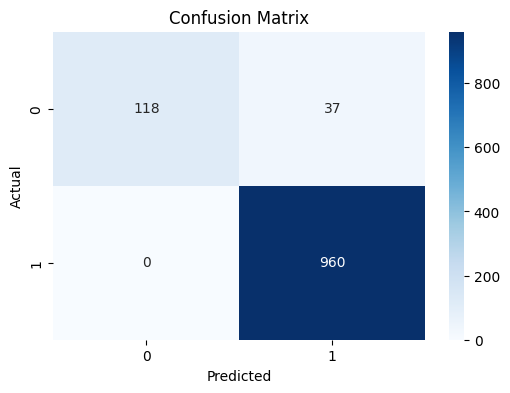

In [61]:
print(classification_report(Y_test, test_data_prediction))

cm = confusion_matrix(Y_test, test_data_prediction)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Building a Predictive System
We test the model on a sample message to predict whether it is spam or ham.

In [62]:
input_mail = ["So ü pay first lar... Then when is da stock comin..."]

# convert data into text
input_data_features = feature_extraction.transform(input_mail)

prediction = model.predict(input_data_features)
# print(prediction)

if prediction[0] == 0:
  print("Spam")
else:
  print("Ham")


Ham


## Conclusion

This project uses TF-IDF vectorization and Logistic Regression to classify messages as spam or ham.

Key observations:
- the model performs well on both training and testing data
- text vectorization is effective for spam detection
- Logistic Regression works well as a baseline text classification model

Future improvements:
- try Naive Bayes
- compare with SVM
- use n-grams
- deploy as a simple web app